In [1]:
%load_ext autoreload
%autoreload 2

In [96]:
%reload_ext autoreload

In [1]:
import pickle as pkl
import numpy as np
from torch.utils.data import DataLoader, random_split

from plots import *
from utils import *
from dataset import *
from vae import *

In [3]:
#on runai
with open('/mydata/cope/mirco/data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/mydata/cope/mirco/data/ssp585_time_series.pkl'

In [2]:
#on local
with open('cope_data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

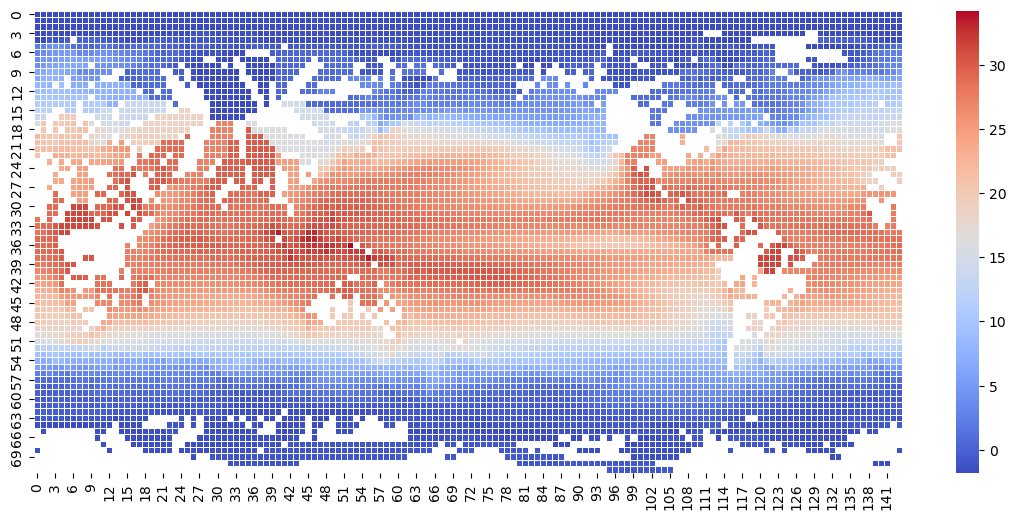

In [4]:
plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

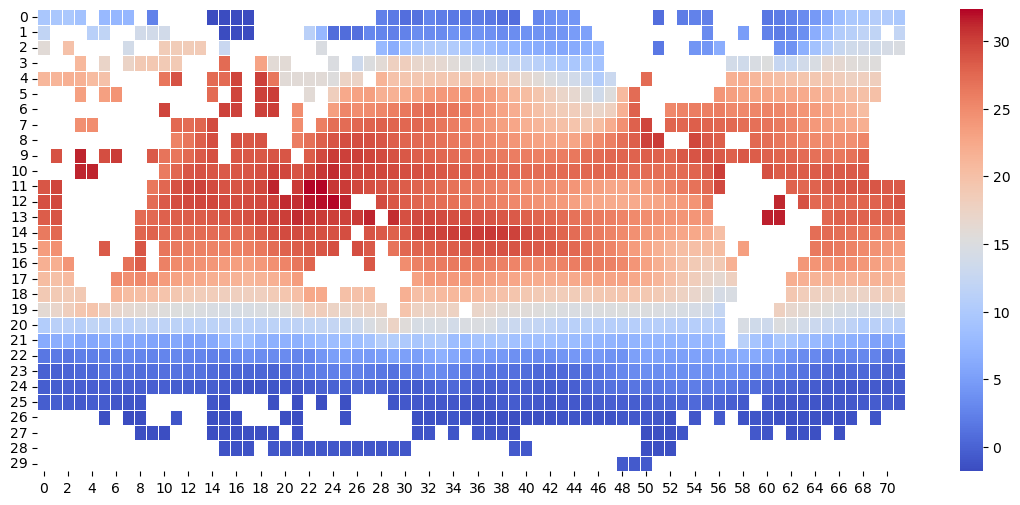

In [3]:
prune(cope_data, min_runs=5)
cut_lat(cope_data, max_lat=60)
downscale(cope_data)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

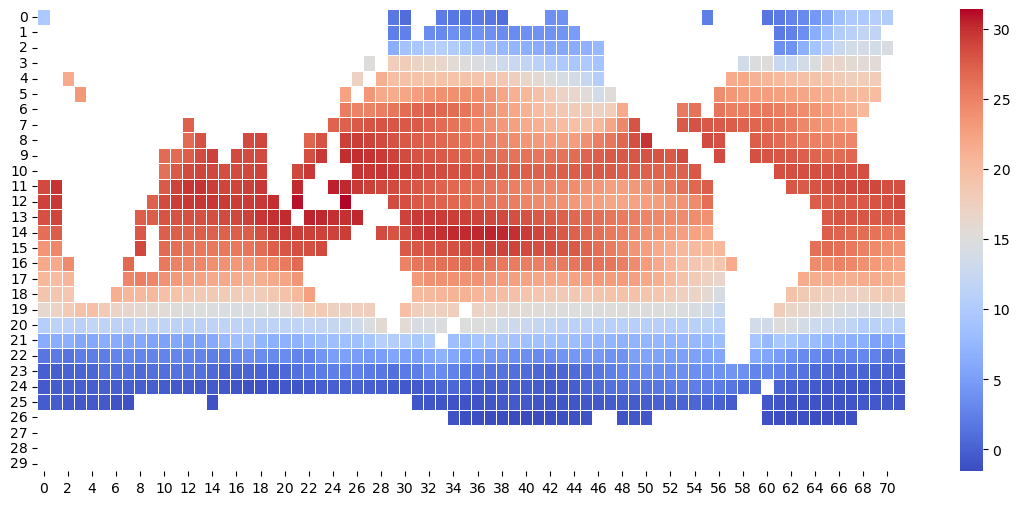

In [4]:
union_nan_mask = find_union_nan_mask(cope_data)
inpute(cope_data, union_nan_mask)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

In [5]:
model = CVAE(mask=union_nan_mask, in_channels=34, hidden_dims=[68, 136], latent_dim=100)

flattened_dim: 19584
encoded_shape: torch.Size([136, 8, 18])


In [6]:
X_train, y_train, X_test, y_test = extract_per_images(cope_data, union_nan_mask, r=[-10, 10])
print(X_train.shape, y_train.shape)

c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:99: RuntimeWarning: Mean of empty slice
  mean_timegrid = np.nanmean(runs_timegrids, axis=0)
c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:100: RuntimeWarning: Mean of empty slice
  mean_grid = np.nanmean(mean_timegrid, axis=0)
c:\Users\mirco\anaconda3\envs\research_project\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:104: RuntimeWarning: Mean of empty slice
  std_grid = np.nanmean(std_timegrid, axis=0)
c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:109: RuntimeWarning: Mean of empty slice
  mean_forced_responses = np.nanmean(runs_timegrids_normalized, axis=0)


(607, 34, 30, 72) (607, 34, 30, 72)


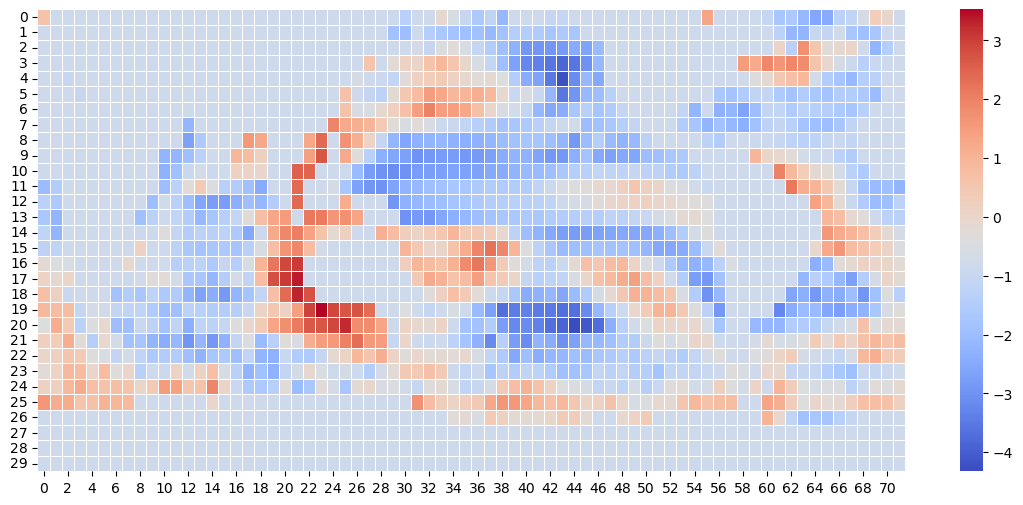

In [57]:
plot_grid(X[0][0])

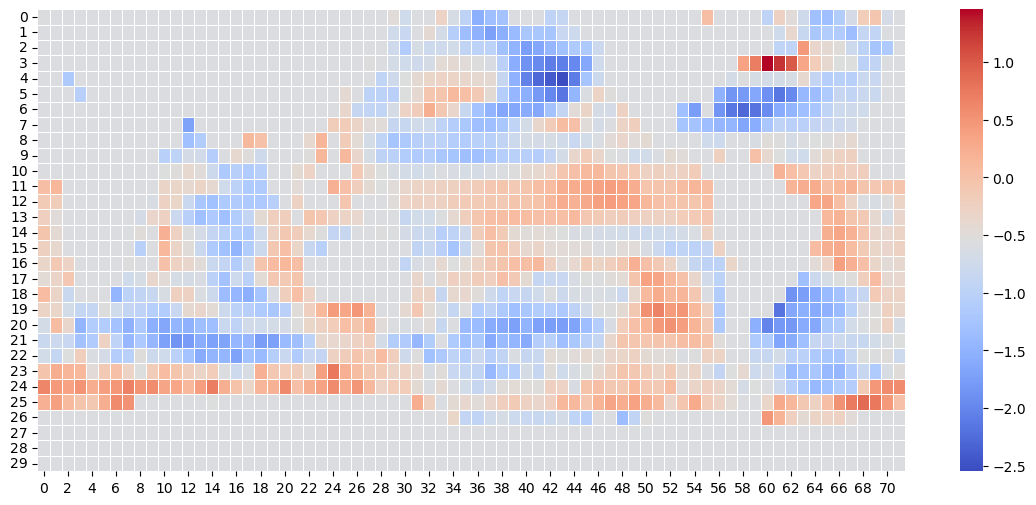

In [58]:
plot_grid(Y[0][0])

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [8]:
batch_size = 16

train_dataset = CopeDataset(samples=X_train, labels=y_train)
test_dataset = CopeDataset(samples=X_test, labels=y_test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [9]:
lr = 1.5e-3
epochs = 50

model = CVAE(mask=union_nan_mask, in_channels=34, hidden_dims=[68, 136], latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print("Start training CVAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = model(x)
        loss = model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training CVAE...
Epoch 1 complete ! 	Average Loss:  5745.763427734375
Epoch 2 complete ! 	Average Loss:  4435.555129592483
Epoch 3 complete ! 	Average Loss:  4302.702366184544
Epoch 4 complete ! 	Average Loss:  4167.79236829603
Epoch 5 complete ! 	Average Loss:  3227.7441439241975
Epoch 6 complete ! 	Average Loss:  2197.054242108319
Epoch 7 complete ! 	Average Loss:  1945.8661548511402
Epoch 8 complete ! 	Average Loss:  1727.626880542652
Epoch 9 complete ! 	Average Loss:  1606.3998726509712
Epoch 10 complete ! 	Average Loss:  1523.2445711702915
Epoch 11 complete ! 	Average Loss:  1468.9621202623523
Epoch 12 complete ! 	Average Loss:  1439.9751191010346
Epoch 13 complete ! 	Average Loss:  1493.2912828600086
Epoch 14 complete ! 	Average Loss:  1432.992585053315
Epoch 15 complete ! 	Average Loss:  1361.913402660473
Epoch 16 complete ! 	Average Loss:  1317.0236568966427
Epoch 17 complete ! 	Average Loss:  1277.8988498997044
Epoch 18 complete ! 	Average Loss:  1236.2353845544762
Epoch

In [186]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)
        x_hat.detach()

        break

x, x_hat, y = x.numpy()[0], x_hat.numpy()[0], y.numpy()[0]

In [187]:
print(x.shape)
print(x_hat.shape)
print(y.shape)

(34, 30, 72)
(34, 30, 72)
(34, 30, 72)


In [188]:
x = fill_grid_timeserie(x, union_nan_mask, method='value', fill_value=np.nan)
x_hat = fill_grid_timeserie(x_hat, union_nan_mask, method='value', fill_value=np.nan)
y = fill_grid_timeserie(y, union_nan_mask, method='value', fill_value=np.nan)

-3.5155842 2.8045485


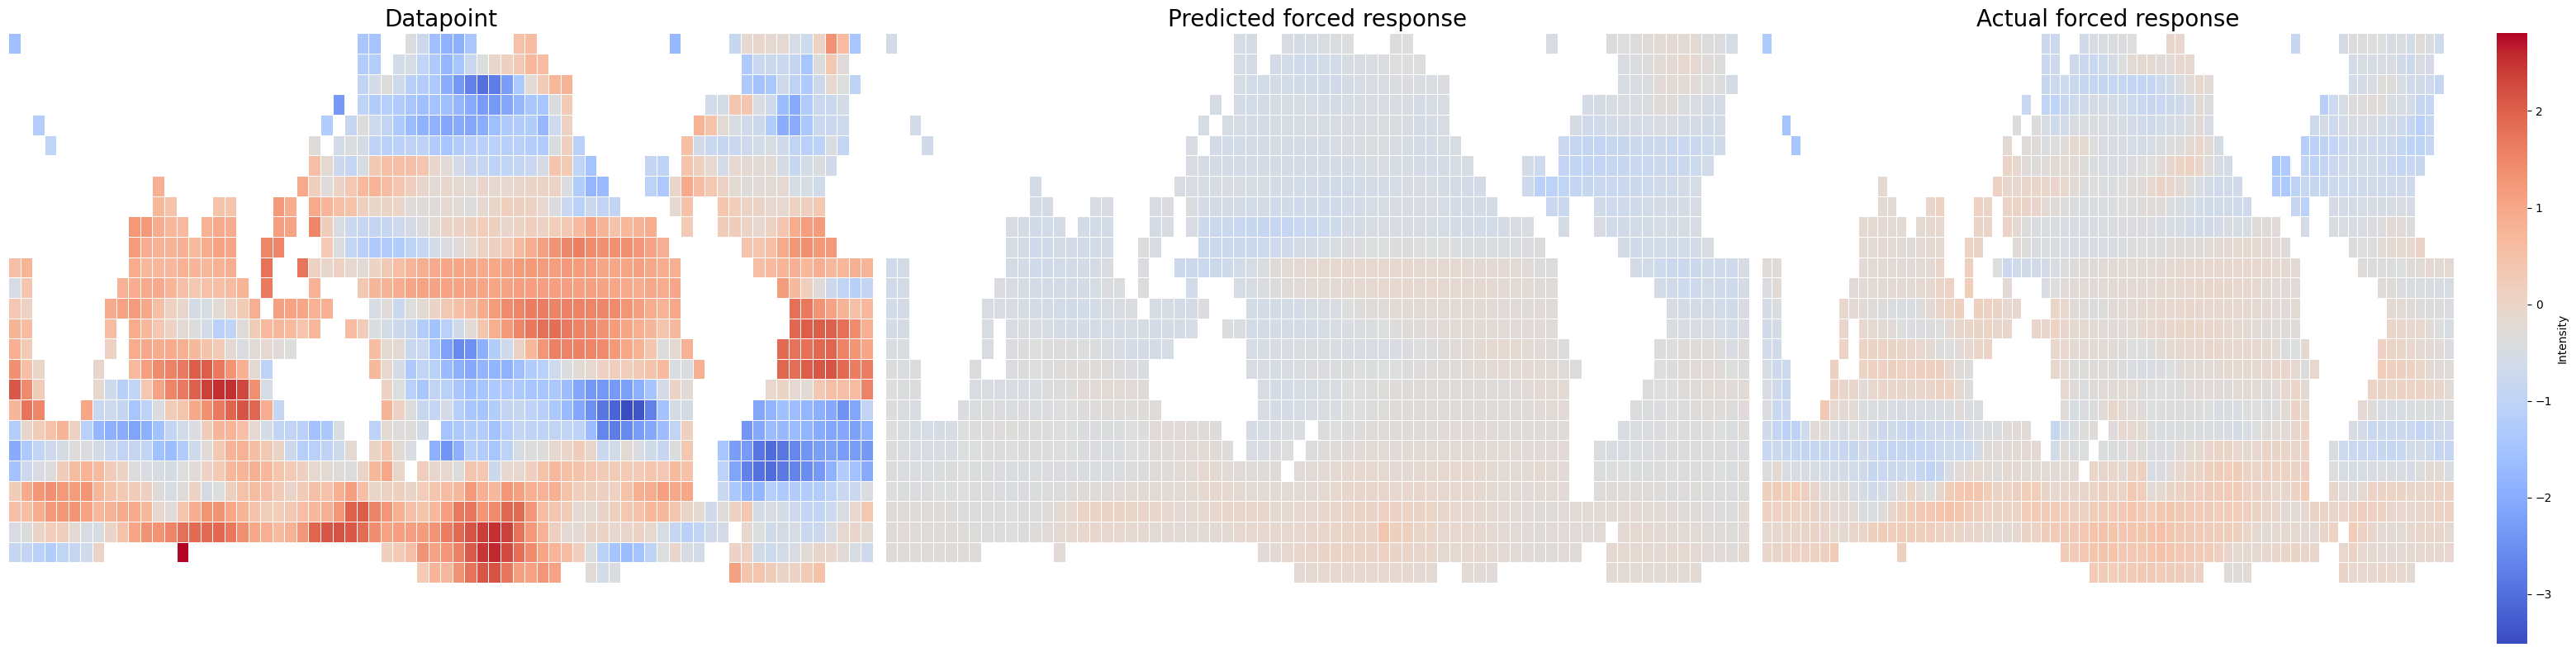

In [189]:
plot_trio_grids(x[0], x_hat[0], y[0], union_nan_mask)

-1.5021956 0.51013947


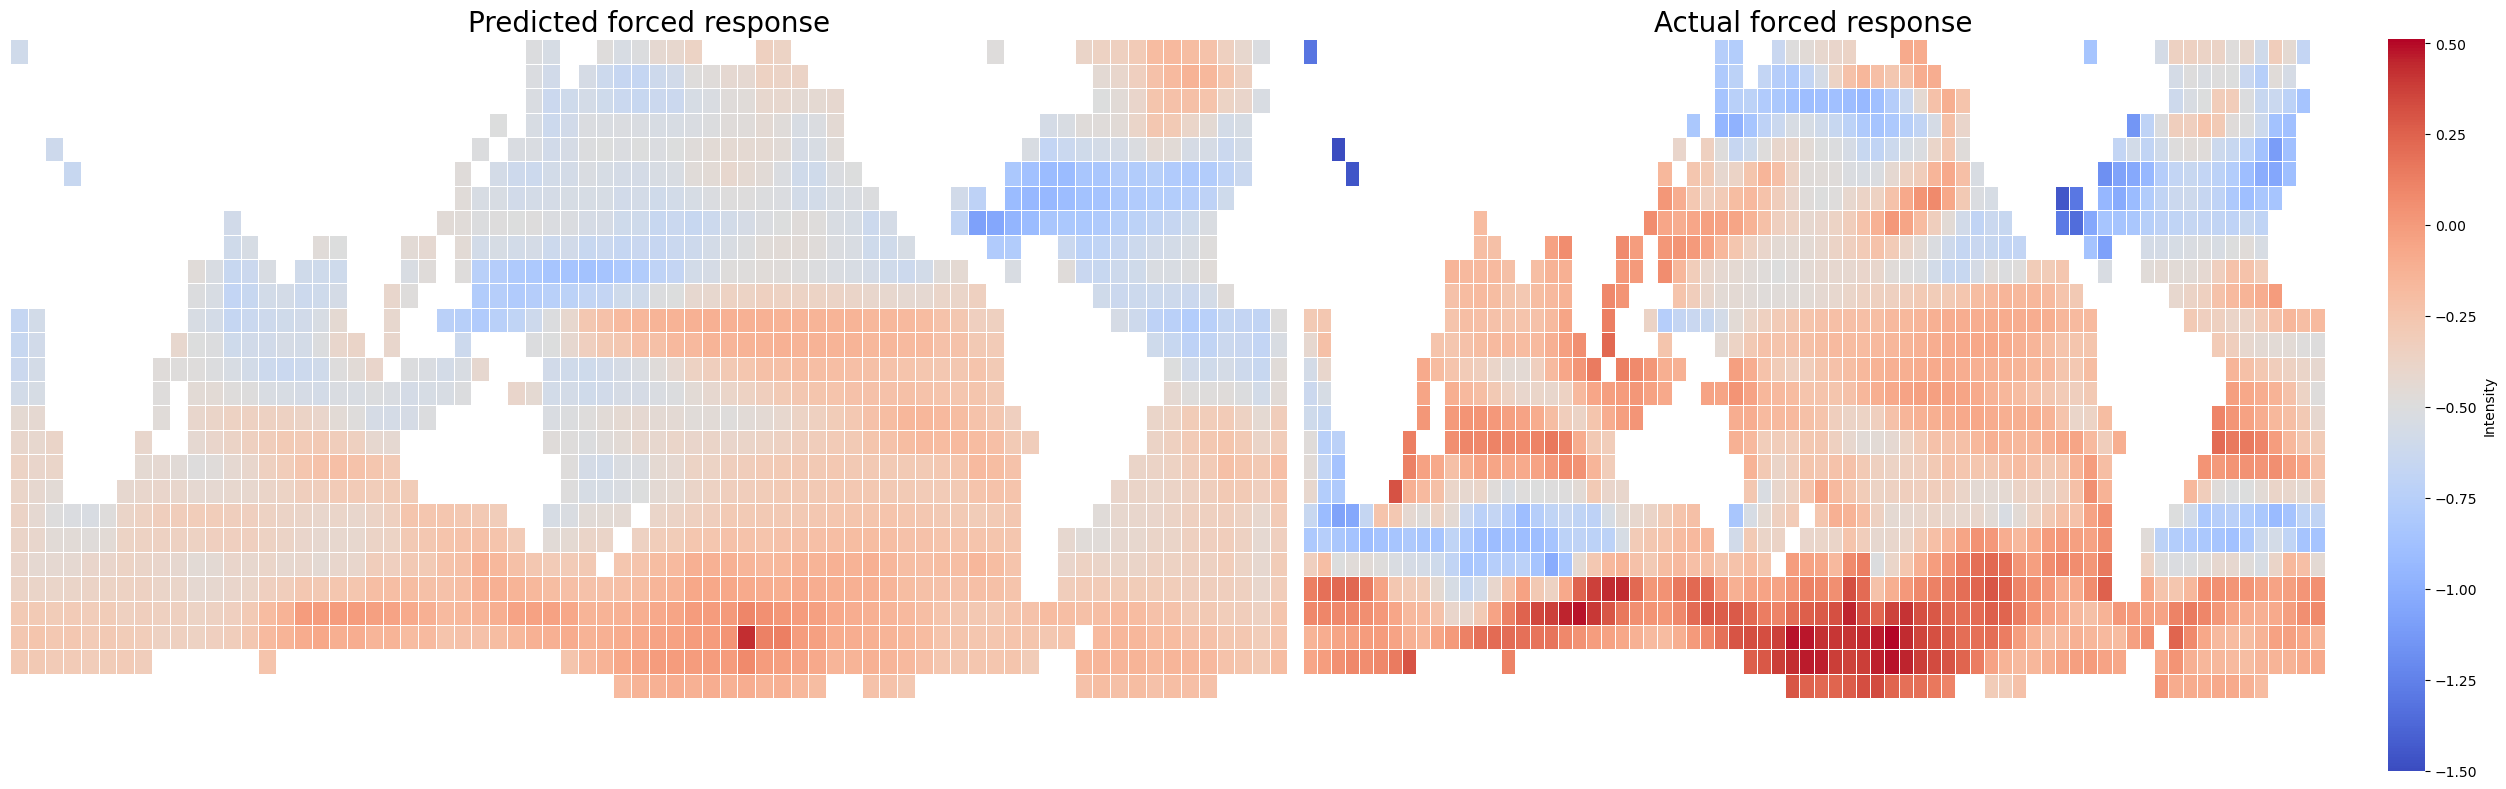

In [190]:
plot_duo_grids(x_hat[0], y[0], union_nan_mask)

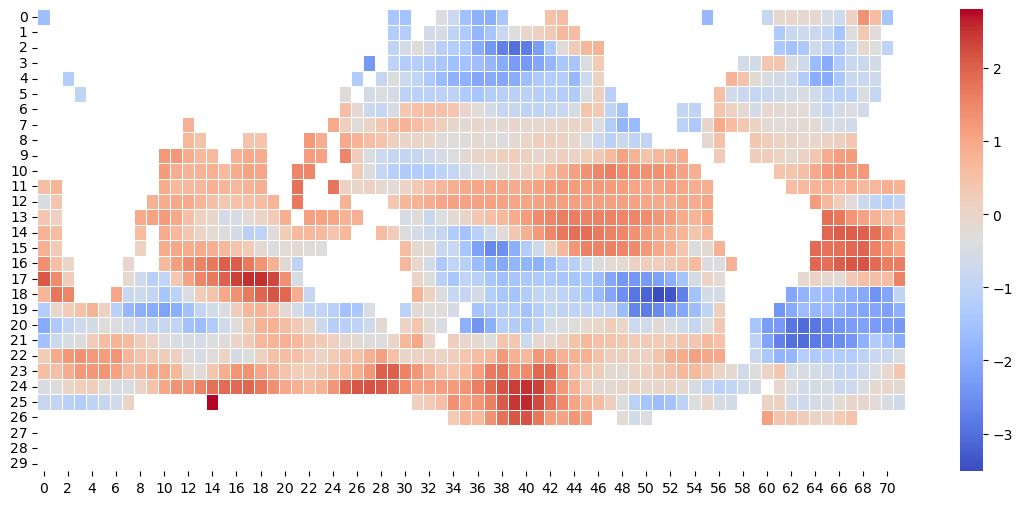

In [191]:
plot_grid(x[0])

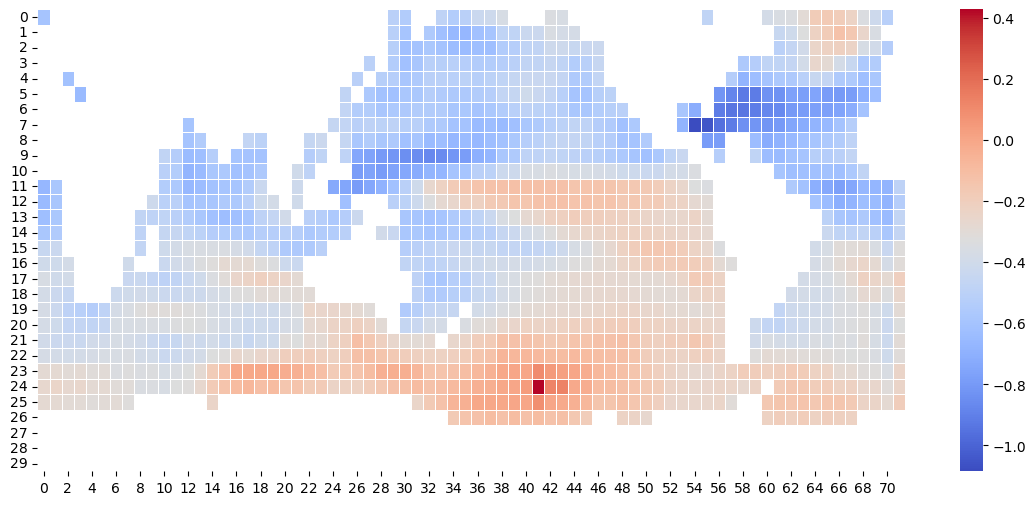

In [192]:
plot_grid(x_hat[0])

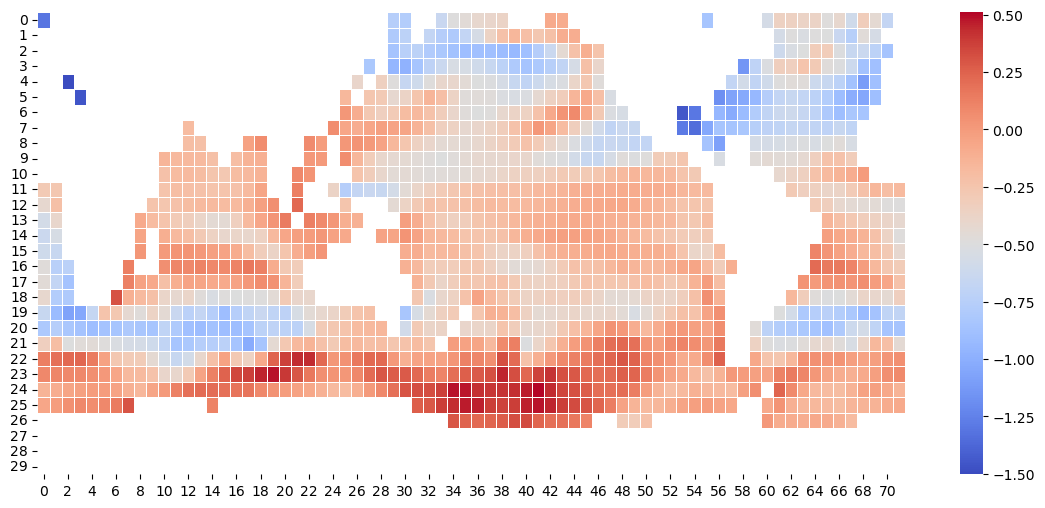

In [193]:
plot_grid(y[0])

In [194]:
x.shape

(34, 30, 72)

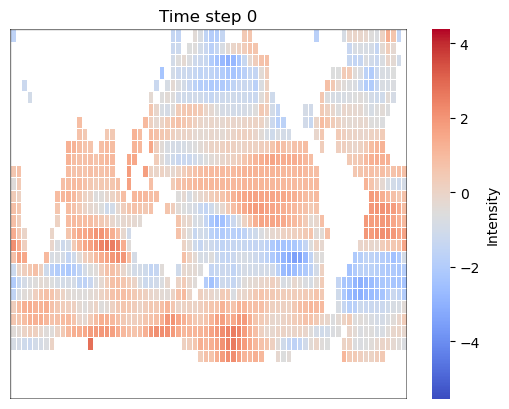

In [197]:
a = get_animated_timeserie(x, union_nan_mask, flattened=False)
a.save('cvae_x.gif', writer='pillow', fps=1)

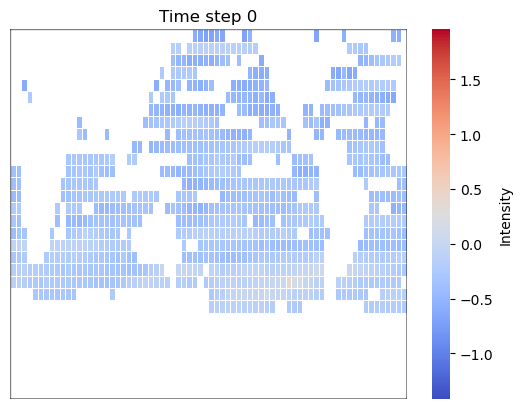

In [202]:
a = get_animated_timeserie(x_hat, union_nan_mask)
a.save('cvae_x_hat.gif', writer='pillow', fps=1)

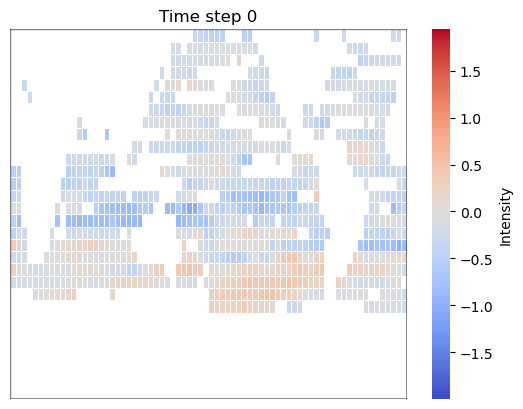

In [203]:
a = get_animated_timeserie(y, union_nan_mask)
a.save('cvae_y.gif', writer='pillow', fps=1)

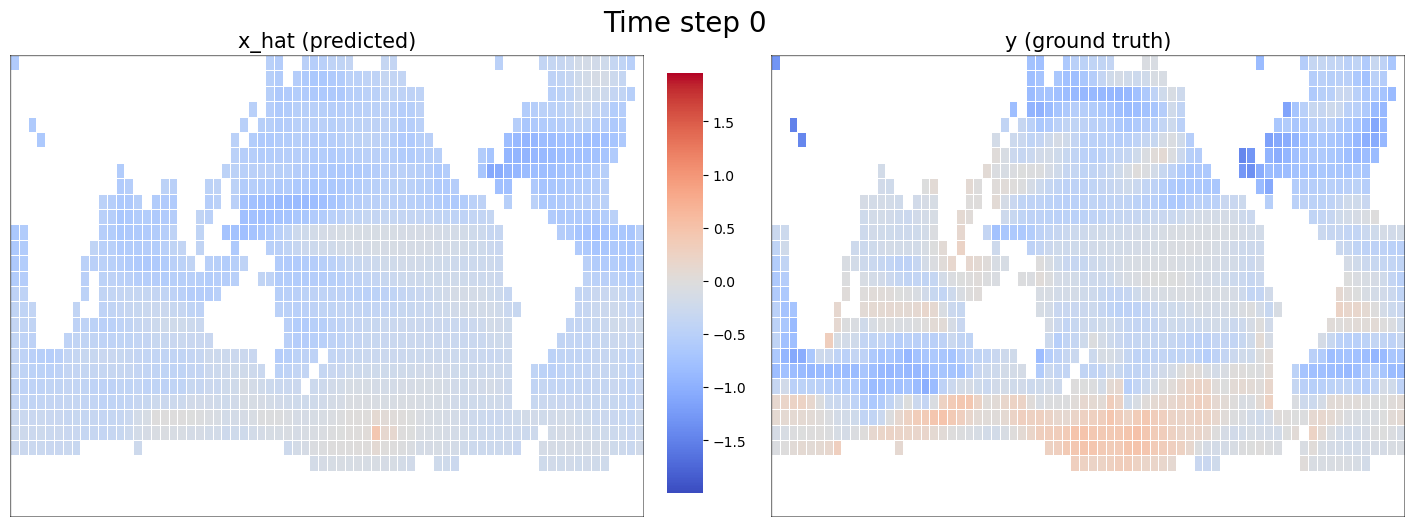

In [201]:
a = get_duo_animated_timeserie(x_hat, y, union_nan_mask, flattened=False)
a.save('cvae_pred_truth.gif', writer='pillow', fps=1)

In [204]:
n_samples = 100

model.eval()
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)[0]
        samples = model.sample(x, n_samples)

        break

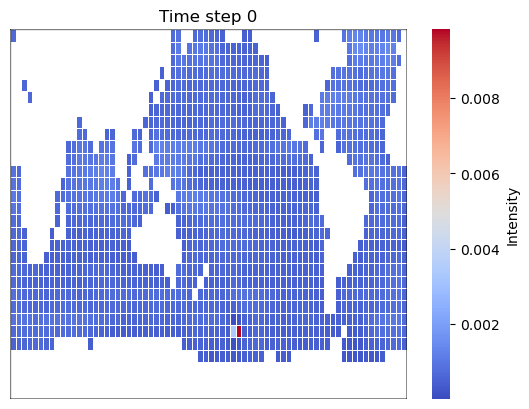

In [207]:
conf_int = get_confidence_interval_grid_timeserie(samples)
conf_int = fill_grid_timeserie(conf_int, union_nan_mask, method='value', fill_value=np.nan)
a = get_animated_timeserie(conf_int, union_nan_mask, flattened=False)
a.save('cvae_confidence_interval.gif', writer='pillow', fps=1)


In [ ]:
epochs = 2
lrs = [1e-3, 1.5e-3, 2e-3]
in_channels = 34
hidden_dims = [[68, 136]]
latent_dims = [100, 200, 300]
configurations = len(lrs)*len(hidden_dims)*len(latent_dims)

batch_size = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

ith = 1

print('Begin CVAE cross validation...\n')

all_mse_losses = {}
all_nmse_losses = {}
for lr in lrs:
    for hidden_dim in hidden_dims:
        for latent_dim in latent_dims:
            model_configs = {'in_channels': in_channels, 'hidden_dim': hidden_dim, 'latent_dim': latent_dim}
            training_configs = {'device': device, 'epochs': epochs, 'batch_size': batch_size, 'lr': lr}

            mse_losses, nmse_losses = CVAE_LOOCV(cope_data, union_nan_mask, model_configs, training_configs)
            
            all_mse_losses[f'cvae_{lr}_{hidden_dim}_{latent_dim}'] = mse_losses
            all_nmse_losses[f'cvae_{lr}_{hidden_dim}_{latent_dim}'] = nmse_losses
            
            print(f'Finished configuration {ith}/{configurations}')
            

            ith += 1

print('\nFinished training !\n')